# Conv-vs-DenseAM Ablation on MNIST 0/1

This notebook asks whether the hybrid model is genuinely using the convolutional Bernoulli hidden units, or whether the global DenseAM prototypes are doing all of the work.

The ablation compares:

- `conv_only`: local convolutional Bernoulli free energy, no DenseAM term.
- `dense_frozen`: DenseAM prototypes are fixed; only visible bias and prototype logits/biases train.
- `dense_train_proto`: DenseAM prototypes train; no conv hidden units.
- `hybrid_frozen_proto`: conv hidden units train, DenseAM prototypes are frozen.
- `hybrid_train_all`: conv hidden units and DenseAM prototypes both train.

The decisive comparison is `dense_frozen` vs `hybrid_frozen_proto`. If the hybrid with frozen prototypes improves, the conv hidden units are doing real local refinement rather than merely helping prototypes memorize.

In [1]:
import math
import time
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX version: 0.4.33
Devices: [CudaDevice(id=0)]
Default backend: gpu


In [2]:
SEED = 0
RESEARCH_MODE = False

IMG_SIDE = 12
DIGITS = (0, 1)

if RESEARCH_MODE:
    N_TRAIN = 4096
    N_VALID = 1024
    N_TIME_SWEEP = 10
    STEPS_PER_TIME_SWEEP = 450
    N_TIME_FINAL = 14
    STEPS_PER_TIME_FINAL = 1800
    BATCH_SIZE = 192
    N_REVERSE_STEPS = 420
    N_SAMPLES = 96
    K_VALUES = [64, 128]
    LAMBDA_VALUES = [0.5, 0.8, 1.0, 1.2]
else:
    N_TRAIN = 2000
    N_VALID = 512
    N_TIME_SWEEP = 8
    STEPS_PER_TIME_SWEEP = 280
    N_TIME_FINAL = 12
    STEPS_PER_TIME_FINAL = 1000
    BATCH_SIZE = 128
    N_REVERSE_STEPS = 320
    N_SAMPLES = 64
    K_VALUES = [64, 128]
    LAMBDA_VALUES = [0.5, 1.0]

INIT_KINDS = ["random", "kmeans"]
MODES = ["dense_frozen", "dense_train_proto", "hybrid_frozen_proto", "hybrid_train_all"]

CONV_HIDDEN_CH = 32
CONV_KERNEL = 5
CONV_W_SCALE = 0.035
HIDDEN_BIAS_SCALE = -1.25

LR = 1e-3
GRAD_CLIP = 10.0
REG_SCALE = 1e-6
PROTO_REG_SCALE = 2e-6

kBT = 1.0
TAU = 3.0
T_MIN = 8e-2
TIME_GRID_SWEEP = jnp.linspace(T_MIN, TAU, N_TIME_SWEEP)
TIME_GRID_FINAL = jnp.linspace(T_MIN, TAU, N_TIME_FINAL)

key = random.PRNGKey(SEED)
print(f"modes={MODES}")
print(f"K={K_VALUES}, lambda={LAMBDA_VALUES}, init={INIT_KINDS}")

modes=['dense_frozen', 'dense_train_proto', 'hybrid_frozen_proto', 'hybrid_train_all']
K=[64, 128], lambda=[0.5, 1.0], init=['random', 'kmeans']


2026-05-22 22:23:47.479129: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params), "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g, state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g), state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps), params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}

## Data

In [4]:
def _load_mnist_raw():
    from tensorflow.keras.datasets import mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    return np.asarray(x_train, dtype=np.uint8), np.asarray(y_train, dtype=np.int32), np.asarray(x_test, dtype=np.uint8), np.asarray(y_test, dtype=np.int32)


def downsample_avg(x_28, out_side):
    k = 28 // out_side
    cropped_side = out_side * k
    pad = (28 - cropped_side) // 2
    x = x_28[:, pad:pad + cropped_side, pad:pad + cropped_side].astype(np.float32) / 255.0
    if k > 1:
        x = x.reshape(-1, out_side, k, out_side, k).mean(axis=(2, 4))
    return x


def prep_mnist_split(x_raw, y_raw, digits, n, out_side, seed):
    mask = np.isin(y_raw, np.asarray(digits))
    x = x_raw[mask]
    y = y_raw[mask]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(x.shape[0])[:n]
    x = downsample_avg(x[idx], out_side)
    x = 2.0 * x - 1.0
    x = x[..., None]
    return jnp.asarray(x), jnp.asarray(y[idx])


x_train_raw, y_train_raw, x_test_raw, y_test_raw = _load_mnist_raw()
train_images, train_labels = prep_mnist_split(x_train_raw, y_train_raw, DIGITS, N_TRAIN, IMG_SIDE, SEED)
valid_images, valid_labels = prep_mnist_split(x_test_raw, y_test_raw, DIGITS, N_VALID, IMG_SIDE, SEED + 1)
print("train_images:", train_images.shape, train_images.dtype)
print("valid_images:", valid_images.shape, valid_images.dtype)
print("train class counts:", {int(d): int(jnp.sum(train_labels == d)) for d in DIGITS})

2026-05-22 22:23:47.728110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779488627.739109  147467 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779488627.742593  147467 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


train_images: (2000, 12, 12, 1) float32
valid_images: (512, 12, 12, 1) float32
train class counts: {0: 943, 1: 1057}


In [5]:
def ou_coeffs(t, kBT_val=1.0):
    a = jnp.exp(-t)
    sigma2 = kBT_val * (1.0 - a * a)
    return a, jnp.maximum(sigma2, 1e-6)


def corrupt_ou(key, x0, t, kBT_val=1.0):
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT_val)
    xt = a * x0 + jnp.sqrt(sigma2) * eps
    target = -kBT_val * (xt - a * x0) / sigma2
    return xt, target

## Model Components

The shared score is

```math
s(x,t)=-x/\sigma_t^2 + b + I_{conv}s_{conv-hidden}(x,t) + I_{dense}\lambda s_{DenseAM}(x,t).
```

We keep the base Gaussian and trainable visible bias in every mode so the comparison does not punish dense-only models for lacking the shared mean field.

In [6]:
def conv_encoder(x, W):
    return lax.conv_general_dilated(x, W, window_strides=(1, 1), padding="SAME", dimension_numbers=("NHWC", "HWIO", "NHWC"))


def conv_transpose_tied(q, W):
    return lax.conv_transpose(q, W, strides=(1, 1), padding="SAME", dimension_numbers=("NHWC", "HWIO", "NHWC"), transpose_kernel=True)


def conv_hidden(params, x):
    z = conv_encoder(x, params["conv"]["W"]) + params["conv"]["a"][None, None, None, :]
    return z, jax.nn.sigmoid(z)


def conv_hidden_score(params, x):
    _, q = conv_hidden(params, x)
    return conv_transpose_tied(q, params["conv"]["W"])


def denseam_logits(params, x, a_t, sigma2):
    x_flat = x.reshape((x.shape[0], -1))
    c = params["dense"]["c"]
    norm = 0.5 * (a_t ** 2) * jnp.sum(c * c, axis=1)
    dot = a_t * (x_flat @ c.T)
    return (dot - norm) / sigma2 + params["dense"]["bias"]


def denseam_responsibilities(params, x, a_t, sigma2):
    return jax.nn.softmax(denseam_logits(params, x, a_t, sigma2), axis=-1)


def denseam_score(params, x, a_t, sigma2, lam):
    r = denseam_responsibilities(params, x, a_t, sigma2)
    pull = r @ params["dense"]["c"]
    return lam * a_t * pull.reshape(x.shape) / sigma2


def score_components(params, x, a_t, sigma2, lam, use_conv, use_dense):
    base = -x / sigma2 + params["base"]["b"]
    conv = conv_hidden_score(params, x) if use_conv else jnp.zeros_like(x)
    dense = denseam_score(params, x, a_t, sigma2, lam) if use_dense else jnp.zeros_like(x)
    return base, conv, dense


def model_score(params, x, a_t, sigma2, lam, use_conv, use_dense):
    base, conv, dense = score_components(params, x, a_t, sigma2, lam, use_conv, use_dense)
    return base + conv + dense


def log_unnormalized(params, x, a_t, sigma2, lam, use_conv, use_dense):
    quad = -0.5 * jnp.sum(x * x, axis=(1, 2, 3)) / sigma2
    visible = jnp.sum(params["base"]["b"] * x, axis=(1, 2, 3))
    out = quad + visible
    if use_conv:
        z, _ = conv_hidden(params, x)
        out = out + jnp.sum(jax.nn.softplus(z), axis=(1, 2, 3))
    if use_dense:
        out = out + lam * logsumexp(denseam_logits(params, x, a_t, sigma2), axis=1)
    return out

## Prototype Initialization Cache

In [7]:
def build_prototype_cache(data, K_values, init_kinds, seed=0):
    flat = np.asarray(data).reshape((data.shape[0], -1)).astype(np.float32)
    cache = {}
    for K in K_values:
        if "random" in init_kinds:
            rng = np.random.default_rng(seed + K)
            idx = rng.choice(flat.shape[0], size=K, replace=False)
            cache[("random", K)] = flat[idx] + 0.01 * rng.standard_normal((K, flat.shape[1])).astype(np.float32)
        if "kmeans" in init_kinds:
            km = KMeans(n_clusters=K, n_init=5, max_iter=100, random_state=seed + K)
            cache[("kmeans", K)] = km.fit(flat).cluster_centers_.astype(np.float32)
    return cache


prototype_cache = build_prototype_cache(train_images, K_VALUES, INIT_KINDS, seed=SEED)
print("prototype cache:", {str(k): v.shape for k, v in prototype_cache.items()})

prototype cache: {"('random', 64)": (64, 144), "('kmeans', 64)": (64, 144), "('random', 128)": (128, 144), "('kmeans', 128)": (128, 144)}


In [8]:
def init_params(key, image_shape, prototypes):
    kW, ka = random.split(key)
    H, W_img, C = image_shape
    return {
        "base": {"b": jnp.zeros((1, H, W_img, C), dtype=jnp.float32)},
        "conv": {
            "W": CONV_W_SCALE * random.normal(kW, (CONV_KERNEL, CONV_KERNEL, C, CONV_HIDDEN_CH)),
            "a": HIDDEN_BIAS_SCALE + 0.01 * random.normal(ka, (CONV_HIDDEN_CH,)),
        },
        "dense": {"c": jnp.asarray(prototypes), "bias": jnp.zeros((prototypes.shape[0],), dtype=jnp.float32)},
    }


def mode_flags(mode):
    if mode == "conv_only":
        return True, False, True, False, False
    if mode == "dense_frozen":
        return False, True, False, False, True
    if mode == "dense_train_proto":
        return False, True, False, True, True
    if mode == "hybrid_frozen_proto":
        return True, True, True, False, True
    if mode == "hybrid_train_all":
        return True, True, True, True, True
    raise ValueError(mode)


def mask_grads(grads, use_conv, use_dense, train_conv, train_proto, train_dense_bias):
    if not train_conv:
        grads["conv"] = jax.tree_util.tree_map(jnp.zeros_like, grads["conv"])
    if not train_proto:
        grads["dense"]["c"] = jnp.zeros_like(grads["dense"]["c"])
    if not train_dense_bias:
        grads["dense"]["bias"] = jnp.zeros_like(grads["dense"]["bias"])
    if not use_dense:
        grads["dense"] = jax.tree_util.tree_map(jnp.zeros_like, grads["dense"])
    if not use_conv:
        grads["conv"] = jax.tree_util.tree_map(jnp.zeros_like, grads["conv"])
    return grads

## Conservative Score Check

In [9]:
def score_autodiff(params, x_batch, a_t, sigma2, lam, use_conv, use_dense):
    def logp_single(x_single):
        return log_unnormalized(params, x_single[None, ...], a_t, sigma2, lam, use_conv, use_dense)[0]
    return jax.vmap(jax.grad(logp_single))(x_batch)


key, k_check = random.split(key)
p_check = init_params(k_check, train_images.shape[1:], prototype_cache[("random", K_VALUES[0])])
x_check = train_images[:4]
for mode in ["conv_only", "dense_frozen", "hybrid_frozen_proto"]:
    use_conv, use_dense, *_ = mode_flags(mode)
    a_t, sigma2 = ou_coeffs(jnp.asarray(0.5), kBT)
    analytic = model_score(p_check, x_check, a_t, sigma2, lam=0.7, use_conv=use_conv, use_dense=use_dense)
    autodiff = score_autodiff(p_check, x_check, a_t, sigma2, lam=0.7, use_conv=use_conv, use_dense=use_dense)
    err = float(jnp.max(jnp.abs(analytic - autodiff)))
    print(f"{mode:20s} max score error={err:.3e}")

conv_only            max score error=2.384e-07


dense_frozen         max score error=1.788e-07
hybrid_frozen_proto  max score error=2.384e-07


## Training And Evaluation Helpers

In [10]:
def dsm_loss(params, key, data, t, batch_size, lam, use_conv, use_dense):
    k_idx, k_noise = random.split(key)
    idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
    x0 = data[idx]
    xt, target = corrupt_ou(k_noise, x0, t, kBT)
    a_t, sigma2 = ou_coeffs(t, kBT)
    pred = model_score(params, xt, a_t, sigma2, lam, use_conv, use_dense)
    mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=(1, 2, 3)))
    reg = REG_SCALE * (tree_sqnorm(params["base"]) + tree_sqnorm(params["conv"])) + PROTO_REG_SCALE * jnp.sum(params["dense"]["c"] ** 2)
    return mse + reg


@partial(jax.jit, static_argnames=("batch_size", "steps", "use_conv", "use_dense", "train_conv", "train_proto", "train_dense_bias"))
def _train_slice_scan(params, opt_state, key, data, t, batch_size, steps, lr, lam, use_conv, use_dense, train_conv, train_proto, train_dense_bias):
    def body(carry, _):
        params, opt_state, key = carry
        key, sub = random.split(key)
        loss_val, grads = jax.value_and_grad(dsm_loss)(params, sub, data, t, batch_size, lam, use_conv, use_dense)
        grads = mask_grads(grads, use_conv, use_dense, train_conv, train_proto, train_dense_bias)
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        return (params, opt_state, key), loss_val
    (params, opt_state, key), losses = lax.scan(body, (params, opt_state, key), xs=None, length=steps)
    return params, opt_state, key, losses


def train_schedule(key, data, mode, prototypes, lam, t_grid, steps_per_time, batch_size, lr=LR, verbose=False):
    use_conv, use_dense, train_conv, train_proto, train_dense_bias = mode_flags(mode)
    key, k_init = random.split(key)
    params = init_params(k_init, data.shape[1:], prototypes)
    params_by_idx = [None for _ in range(len(t_grid))]
    losses_by_idx = [None for _ in range(len(t_grid))]
    wall0 = time.time()
    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        params, opt_state, key, losses = _train_slice_scan(
            params, opt_state, key, data, t, batch_size, steps_per_time, lr, lam,
            use_conv, use_dense, train_conv, train_proto, train_dense_bias,
        )
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(losses))
        if verbose:
            _, sigma2 = ou_coeffs(t, kBT)
            print(f"{mode:20s} | t={float(t):.3f} sigma2={float(sigma2):.4f} loss={float(losses[-1]):.4e}")
    return params_by_idx, losses_by_idx, time.time() - wall0, key

In [11]:
def stack_params(params_seq):
    return {
        "base": {"b": jnp.stack([p["base"]["b"] for p in params_seq], axis=0)},
        "conv": {
            "W": jnp.stack([p["conv"]["W"] for p in params_seq], axis=0),
            "a": jnp.stack([p["conv"]["a"] for p in params_seq], axis=0),
        },
        "dense": {
            "c": jnp.stack([p["dense"]["c"] for p in params_seq], axis=0),
            "bias": jnp.stack([p["dense"]["bias"] for p in params_seq], axis=0),
        },
    }


def params_at(stacked, idx):
    return {
        "base": {"b": stacked["base"]["b"][idx]},
        "conv": {"W": stacked["conv"]["W"][idx], "a": stacked["conv"]["a"][idx]},
        "dense": {"c": stacked["dense"]["c"][idx], "bias": stacked["dense"]["bias"][idx]},
    }


@partial(jax.jit, static_argnames=("batch_size", "use_conv", "use_dense"))
def validation_dsm_loss(stacked, key, data, t_grid, batch_size, lam, use_conv, use_dense):
    time_indices = jnp.arange(t_grid.shape[0], dtype=jnp.int32)
    def one_time(carry, t_idx):
        key = carry
        key, k_idx, k_noise = random.split(key, 3)
        t = t_grid[t_idx]
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT)
        a_t, sigma2 = ou_coeffs(t, kBT)
        params = params_at(stacked, t_idx)
        pred = model_score(params, xt, a_t, sigma2, lam, use_conv, use_dense)
        loss = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=(1, 2, 3)))
        return key, loss
    _, losses = lax.scan(one_time, key, time_indices)
    return jnp.mean(losses)


def build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val):
    dt = tau / n_steps
    ss = jnp.maximum(t_min, tau - jnp.arange(n_steps) * dt)
    a_s, sigma2_s = ou_coeffs(ss, kBT_val)
    idx = jnp.argmin(jnp.abs(ss[:, None] - t_grid[None, :]), axis=1).astype(jnp.int32)
    return dt, a_s, sigma2_s, idx


@partial(jax.jit, static_argnames=("n_samples", "n_steps", "clip_x", "sampler", "final_denoise", "use_conv", "use_dense"))
def reverse_sample(key, stacked, t_grid, lam, n_samples, n_steps, use_conv, use_dense, tau=TAU, t_min=T_MIN, kBT_val=kBT, clip_x=2.0, sampler="sde", final_denoise=True):
    key, k_init = random.split(key)
    image_shape = stacked["base"]["b"].shape[2:]
    x = jnp.sqrt(kBT_val) * random.normal(k_init, (n_samples,) + image_shape)
    dt, a_s, sigma2_s, idx_s = build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val)
    def body(carry, step_inputs):
        x, key = carry
        a_t, sigma2, idx = step_inputs
        params = params_at(stacked, idx)
        score = model_score(params, x, a_t, sigma2, lam, use_conv, use_dense)
        key, k_noise = random.split(key)
        if sampler == "sde":
            x = x + (x + 2.0 * score) * dt + jnp.sqrt(2.0 * kBT_val * dt) * random.normal(k_noise, x.shape)
        else:
            x = x + (x + score) * dt
        x = jnp.clip(x, -clip_x, clip_x)
        return (x, key), x
    (x_final, key), _ = lax.scan(body, (x, key), (a_s, sigma2_s, idx_s))
    if final_denoise:
        a_min, sigma2_min = ou_coeffs(t_min, kBT_val)
        params_min = params_at(stacked, jnp.array(0, dtype=jnp.int32))
        score_min = model_score(params_min, x_final, a_min, sigma2_min, lam, use_conv, use_dense)
        x_final = (x_final + sigma2_min * score_min) / jnp.maximum(a_min, 1e-6)
        x_final = jnp.clip(x_final, -1.0, 1.0)
    return x_final, key

In [12]:
def flatten_images(x):
    return np.asarray(x).reshape((x.shape[0], -1))


def pairwise_l2(a, b, block=256):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    out = np.empty((a.shape[0], b.shape[0]), dtype=np.float32)
    bn = np.sum(b * b, axis=1)
    for i in range(0, a.shape[0], block):
        ai = a[i:i + block]
        an = np.sum(ai * ai, axis=1, keepdims=True)
        d2 = an + bn[None, :] - 2.0 * ai @ b.T
        out[i:i + block] = np.sqrt(np.maximum(d2, 0.0))
    return out


def sample_diagnostics(samples, train_x, train_y, prototypes_flat=None):
    s = flatten_images(samples)
    tr = flatten_images(train_x)
    d_st = pairwise_l2(s, tr)
    nn_idx = d_st.argmin(axis=1)
    pred_digits = np.asarray(train_y)[nn_idx]
    control_n = min(768, tr.shape[0])
    tr_control = tr[:control_n]
    d_tt = pairwise_l2(tr_control, tr_control)
    np.fill_diagonal(d_tt, np.inf)
    # Generated sample diversity: nearest other generated sample.
    d_ss = pairwise_l2(s, s)
    np.fill_diagonal(d_ss, np.inf)
    out = {
        "d_sample_train": d_st.min(axis=1),
        "d_train_train": d_tt.min(axis=1),
        "d_sample_sample": d_ss.min(axis=1),
        "pred_digits": pred_digits,
        "nearest_train_idx": nn_idx,
    }
    if prototypes_flat is not None:
        out["d_sample_proto"] = pairwise_l2(s, np.asarray(prototypes_flat)).min(axis=1)
    return out


def summarize_diag(diag):
    counts = {int(d): int(np.sum(diag["pred_digits"] == d)) for d in DIGITS}
    out = {
        "median_sample_to_train": float(np.median(diag["d_sample_train"])),
        "median_train_to_train": float(np.median(diag["d_train_train"])),
        "median_sample_to_sample": float(np.median(diag["d_sample_sample"])),
        "zero_frac": float(np.mean(diag["pred_digits"] == 0)),
        "digit_counts": counts,
    }
    if "d_sample_proto" in diag:
        out["median_sample_to_proto"] = float(np.median(diag["d_sample_proto"]))
    return out


@partial(jax.jit, static_argnames=("use_conv", "use_dense"))
def component_norms(stacked, x, t_idx, t_grid, lam, use_conv, use_dense):
    t = t_grid[t_idx]
    a_t, sigma2 = ou_coeffs(t, kBT)
    params = params_at(stacked, t_idx)
    base, conv, dense = score_components(params, x, a_t, sigma2, lam, use_conv, use_dense)
    def rms(v):
        return jnp.sqrt(jnp.mean(jnp.sum(v * v, axis=(1, 2, 3))))
    return {"base": rms(base), "conv": rms(conv), "dense": rms(dense), "total": rms(base + conv + dense)}


def show_image_grid(arr, title, n_show=64, n_cols=8, vmin=-1.0, vmax=1.0):
    arr = np.asarray(arr)
    n = min(n_show, arr.shape[0])
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(0.85 * n_cols, 0.85 * n_rows))
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(arr[i, :, :, 0], cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

## Sweep

For speed, `conv_only` is run once. Dense and hybrid modes are swept over `K`, `lambda`, and initialization.

In [13]:
configs = [{"mode": "conv_only", "init": "random", "K": K_VALUES[0], "lambda": 0.0}]
for init_kind in INIT_KINDS:
    for K in K_VALUES:
        for lam in LAMBDA_VALUES:
            for mode in MODES:
                configs.append({"mode": mode, "init": init_kind, "K": K, "lambda": lam})

sweep_results = []
for i, cfg in enumerate(configs, 1):
    mode, init_kind, K, lam = cfg["mode"], cfg["init"], int(cfg["K"]), float(cfg["lambda"])
    print(f"\n=== ablation {i}/{len(configs)}: {mode}, init={init_kind}, K={K}, lambda={lam} ===")
    protos = prototype_cache[(init_kind, K)]
    key, sub = random.split(key)
    params_seq, losses, wall, key = train_schedule(sub, train_images, mode, protos, lam, TIME_GRID_SWEEP, STEPS_PER_TIME_SWEEP, BATCH_SIZE, verbose=False)
    stacked = stack_params(params_seq)
    use_conv, use_dense, *_ = mode_flags(mode)
    key, sub = random.split(key)
    val_loss = validation_dsm_loss(stacked, sub, valid_images, TIME_GRID_SWEEP, min(128, BATCH_SIZE), lam, use_conv, use_dense)
    key, sub = random.split(key)
    samples, key = reverse_sample(sub, stacked, TIME_GRID_SWEEP, lam, N_SAMPLES, N_REVERSE_STEPS, use_conv, use_dense)
    proto_flat = np.asarray(params_seq[0]["dense"]["c"]) if use_dense else None
    diag = sample_diagnostics(samples, train_images, train_labels, prototypes_flat=proto_flat)
    summary = summarize_diag(diag)
    norms = component_norms(stacked, samples, jnp.array(0, dtype=jnp.int32), TIME_GRID_SWEEP, lam, use_conv, use_dense)
    norms = {k: float(v) for k, v in jax.device_get(norms).items()}
    row = {**cfg, "params_seq": params_seq, "samples": samples, "losses": losses, "wall": wall, "val_loss": float(val_loss), "final_train_loss": float(np.mean([lh[-1] for lh in losses])), **summary, "norms": norms}
    sweep_results.append(row)
    print(f"val={row['val_loss']:.3f} train={row['final_train_loss']:.3f} sample->train={row['median_sample_to_train']:.3f} control={row['median_train_to_train']:.3f} sample->sample={row['median_sample_to_sample']:.3f} zero_frac={row['zero_frac']:.2f} wall={wall:.1f}s")
    print("counts:", row["digit_counts"], "norms:", norms)

# Category winners by sample placement with non-collapsed class balance.
winners = {}
for mode in ["conv_only", "dense_frozen", "dense_train_proto", "hybrid_frozen_proto", "hybrid_train_all"]:
    rows = [r for r in sweep_results if r["mode"] == mode and 0.10 <= r["zero_frac"] <= 0.90]
    if not rows:
        rows = [r for r in sweep_results if r["mode"] == mode]
    winners[mode] = min(rows, key=lambda r: r["median_sample_to_train"])

print("\ncategory winners:")
for mode, row in winners.items():
    print(mode, {k: row[k] for k in ["init", "K", "lambda", "val_loss", "median_sample_to_train", "median_sample_to_sample", "zero_frac", "digit_counts"]})


=== ablation 1/33: conv_only, init=random, K=64, lambda=0.0 ===


val=23.834 train=22.658 sample->train=4.131 control=2.540 sample->sample=3.651 zero_frac=0.14 wall=1.9s
counts: {0: 9, 1: 55} norms: {'base': 73.48106384277344, 'conv': 71.02349090576172, 'dense': 0.0, 'total': 7.941379070281982}

=== ablation 2/33: dense_frozen, init=random, K=64, lambda=0.5 ===


val=74.155 train=73.755 sample->train=4.609 control=2.540 sample->sample=0.006 zero_frac=0.36 wall=2.6s
counts: {0: 23, 1: 41} norms: {'base': 37.816558837890625, 'conv': 0.0, 'dense': 34.46772384643555, 'total': 3.4780752658843994}

=== ablation 3/33: dense_train_proto, init=random, K=64, lambda=0.5 ===


val=68.323 train=65.701 sample->train=6.578 control=2.540 sample->sample=0.000 zero_frac=0.47 wall=1.6s
counts: {0: 30, 1: 34} norms: {'base': 27.627565383911133, 'conv': 0.0, 'dense': 25.086456298828125, 'total': 2.605266571044922}

=== ablation 4/33: hybrid_frozen_proto, init=random, K=64, lambda=0.5 ===


val=22.777 train=19.909 sample->train=1.460 control=2.540 sample->sample=1.936 zero_frac=0.44 wall=3.0s
counts: {0: 28, 1: 36} norms: {'base': 71.54557037353516, 'conv': 33.92711639404297, 'dense': 34.30229949951172, 'total': 6.465111255645752}

=== ablation 5/33: hybrid_train_all, init=random, K=64, lambda=0.5 ===


...

val=16.497 train=14.816 sample->train=2.313 control=2.540 sample->sample=2.409 zero_frac=0.50 wall=0.5s
counts: {0: 32, 1: 32} norms: {'base': 70.38084411621094, 'conv': 34.08379364013672, 'dense': 33.01651382446289, 'total': 6.451967239379883}

=== ablation 29/33: hybrid_train_all, init=kmeans, K=128, lambda=0.5 ===


val=18.117 train=17.315 sample->train=2.573 control=2.540 sample->sample=2.028 zero_frac=0.59 wall=0.5s
counts: {0: 38, 1: 26} norms: {'base': 68.88362884521484, 'conv': 42.56392288208008, 'dense': 25.944671630859375, 'total': 6.639005661010742}

=== ablation 30/33: dense_frozen, init=kmeans, K=128, lambda=1.0 ===
val=29.134 train=22.066 sample->train=1.801 control=2.540 sample->sample=1.079 zero_frac=0.48 wall=0.1s
counts: {0: 31, 1: 33} norms: {'base': 71.38927459716797, 'conv': 0.0, 'dense': 65.92732238769531, 'total': 5.463296890258789}

=== ablation 31/33: dense_train_proto, init=kmeans, K=128, lambda=1.0 ===


val=30.159 train=29.746 sample->train=2.559 control=2.540 sample->sample=1.917 zero_frac=0.50 wall=0.2s
counts: {0: 32, 1: 32} norms: {'base': 58.5689811706543, 'conv': 0.0, 'dense': 53.74782943725586, 'total': 4.832390785217285}

=== ablation 32/33: hybrid_frozen_proto, init=kmeans, K=128, lambda=1.0 ===


val=22.275 train=17.870 sample->train=1.929 control=2.540 sample->sample=2.328 zero_frac=0.56 wall=0.5s
counts: {0: 36, 1: 28} norms: {'base': 72.56098937988281, 'conv': 5.846295356750488, 'dense': 65.46185302734375, 'total': 4.741202354431152}

=== ablation 33/33: hybrid_train_all, init=kmeans, K=128, lambda=1.0 ===


val=19.939 train=17.283 sample->train=1.508 control=2.540 sample->sample=2.400 zero_frac=0.47 wall=0.6s
counts: {0: 30, 1: 34} norms: {'base': 71.8497314453125, 'conv': 20.401994705200195, 'dense': 48.73588180541992, 'total': 4.744593620300293}

category winners:
conv_only {'init': 'random', 'K': 64, 'lambda': 0.0, 'val_loss': 23.83361053466797, 'median_sample_to_train': 4.130584716796875, 'median_sample_to_sample': 3.6514511108398438, 'zero_frac': 0.140625, 'digit_counts': {0: 9, 1: 55}}
dense_frozen {'init': 'random', 'K': 128, 'lambda': 1.0, 'val_loss': 35.416812896728516, 'median_sample_to_train': 0.22083264589309692, 'median_sample_to_sample': 2.038433790206909, 'zero_frac': 0.421875, 'digit_counts': {0: 27, 1: 37}}
dense_train_proto {'init': 'random', 'K': 64, 'lambda': 1.0, 'val_loss': 31.663589477539062, 'median_sample_to_train': 1.5423152446746826, 'median_sample_to_sample': 0.005524271633476019, 'zero_frac': 0.328125, 'digit_counts': {0: 21, 1: 43}}
hybrid_frozen_proto {'init

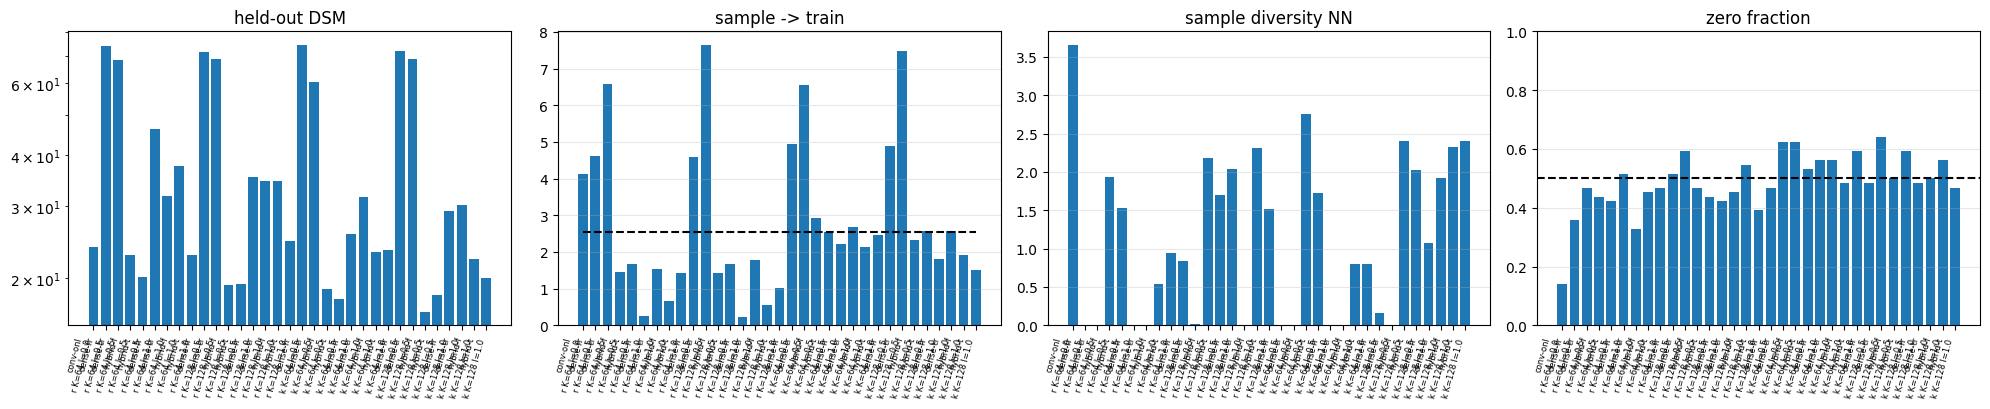

In [14]:
labels = [f"{r['mode'].replace('_', '-')[:8]}\n{r['init'][0]} K={r['K']} l={r['lambda']}" for r in sweep_results]
xs = np.arange(len(sweep_results))
fig, axes = plt.subplots(1, 4, figsize=(20.0, 4.2))
axes[0].bar(xs, [r["val_loss"] for r in sweep_results]); axes[0].set_yscale("log"); axes[0].set_title("held-out DSM")
axes[1].bar(xs, [r["median_sample_to_train"] for r in sweep_results]); axes[1].plot(xs, [r["median_train_to_train"] for r in sweep_results], "k--"); axes[1].set_title("sample -> train")
axes[2].bar(xs, [r["median_sample_to_sample"] for r in sweep_results]); axes[2].set_title("sample diversity NN")
axes[3].bar(xs, [r["zero_frac"] for r in sweep_results]); axes[3].axhline(0.5, color="k", linestyle="--"); axes[3].set_ylim(0, 1); axes[3].set_title("zero fraction")
for ax in axes:
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=6)
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Final Retrains Of Category Winners

We retrain the best configuration from each category with a longer schedule. This is the fairer answer to the question: if prototypes are fixed, how much does the conv layer help?

In [15]:
final_results = []
for mode in ["conv_only", "dense_frozen", "dense_train_proto", "hybrid_frozen_proto", "hybrid_train_all"]:
    w = winners[mode]
    init_kind, K, lam = w["init"], int(w["K"]), float(w["lambda"])
    print(f"\n=== final retrain: {mode}, init={init_kind}, K={K}, lambda={lam} ===")
    protos = prototype_cache[(init_kind, K)]
    key, sub = random.split(key)
    params_seq, losses, wall, key = train_schedule(sub, train_images, mode, protos, lam, TIME_GRID_FINAL, STEPS_PER_TIME_FINAL, BATCH_SIZE, verbose=False)
    stacked = stack_params(params_seq)
    use_conv, use_dense, *_ = mode_flags(mode)
    key, sub = random.split(key)
    val_loss = validation_dsm_loss(stacked, sub, valid_images, TIME_GRID_FINAL, min(128, BATCH_SIZE), lam, use_conv, use_dense)
    key, sub = random.split(key)
    samples, key = reverse_sample(sub, stacked, TIME_GRID_FINAL, lam, N_SAMPLES, N_REVERSE_STEPS, use_conv, use_dense)
    proto_flat = np.asarray(params_seq[0]["dense"]["c"]) if use_dense else None
    diag = sample_diagnostics(samples, train_images, train_labels, prototypes_flat=proto_flat)
    summary = summarize_diag(diag)
    norms = component_norms(stacked, samples, jnp.array(0, dtype=jnp.int32), TIME_GRID_FINAL, lam, use_conv, use_dense)
    norms = {k: float(v) for k, v in jax.device_get(norms).items()}
    row = {"mode": mode, "init": init_kind, "K": K, "lambda": lam, "params_seq": params_seq, "samples": samples, "diag": diag, "wall": wall, "val_loss": float(val_loss), **summary, "norms": norms}
    final_results.append(row)
    print(f"val={row['val_loss']:.3f} sample->train={row['median_sample_to_train']:.3f} control={row['median_train_to_train']:.3f} sample->sample={row['median_sample_to_sample']:.3f} zero_frac={row['zero_frac']:.2f} counts={row['digit_counts']} norms={norms}")


=== final retrain: conv_only, init=random, K=64, lambda=0.0 ===


val=14.231 sample->train=3.998 control=2.540 sample->sample=3.584 zero_frac=0.11 counts={0: 7, 1: 57} norms={'base': 68.71683502197266, 'conv': 65.7292251586914, 'dense': 0.0, 'total': 8.222822189331055}

=== final retrain: dense_frozen, init=random, K=128, lambda=1.0 ===


val=27.400 sample->train=0.304 control=2.540 sample->sample=2.290 zero_frac=0.44 counts={0: 28, 1: 36} norms={'base': 73.95977783203125, 'conv': 0.0, 'dense': 68.59712982177734, 'total': 5.407425403594971}

=== final retrain: dense_train_proto, init=random, K=64, lambda=1.0 ===


val=21.795 sample->train=1.282 control=2.540 sample->sample=0.000 zero_frac=0.44 counts={0: 28, 1: 36} norms={'base': 58.75212478637695, 'conv': 0.0, 'dense': 53.55241775512695, 'total': 5.256309509277344}

=== final retrain: hybrid_frozen_proto, init=random, K=128, lambda=1.0 ===


val=25.267 sample->train=0.738 control=2.540 sample->sample=0.647 zero_frac=0.50 counts={0: 32, 1: 32} norms={'base': 75.42974090576172, 'conv': 7.142251491546631, 'dense': 68.32754516601562, 'total': 5.49801778793335}

=== final retrain: hybrid_train_all, init=random, K=128, lambda=1.0 ===


val=12.638 sample->train=1.551 control=2.540 sample->sample=1.426 zero_frac=0.45 counts={0: 29, 1: 35} norms={'base': 68.14937591552734, 'conv': 43.883548736572266, 'dense': 26.149354934692383, 'total': 5.88041353225708}


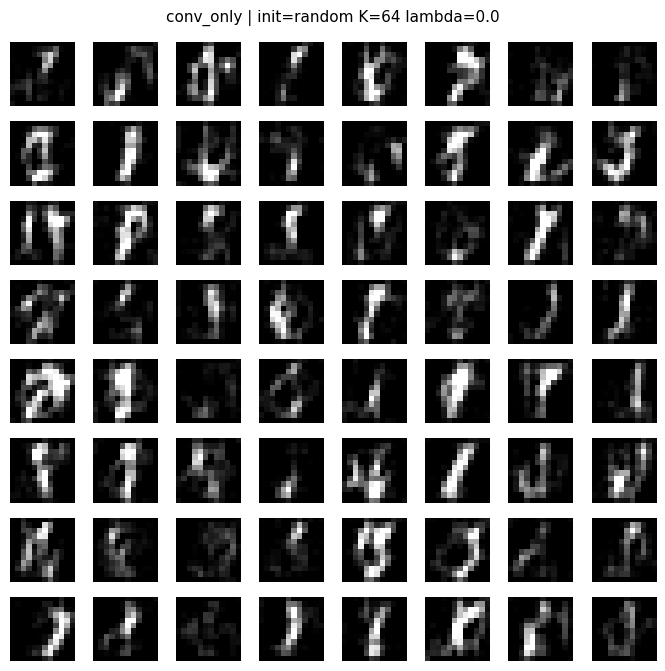

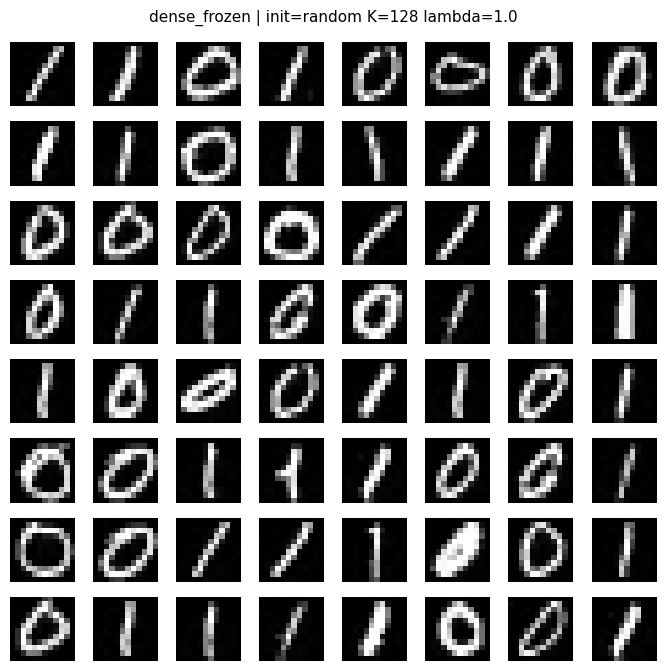

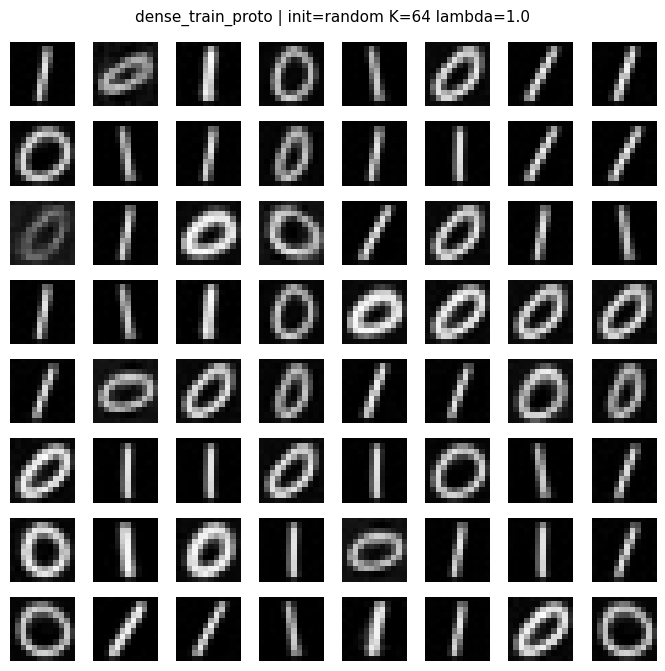

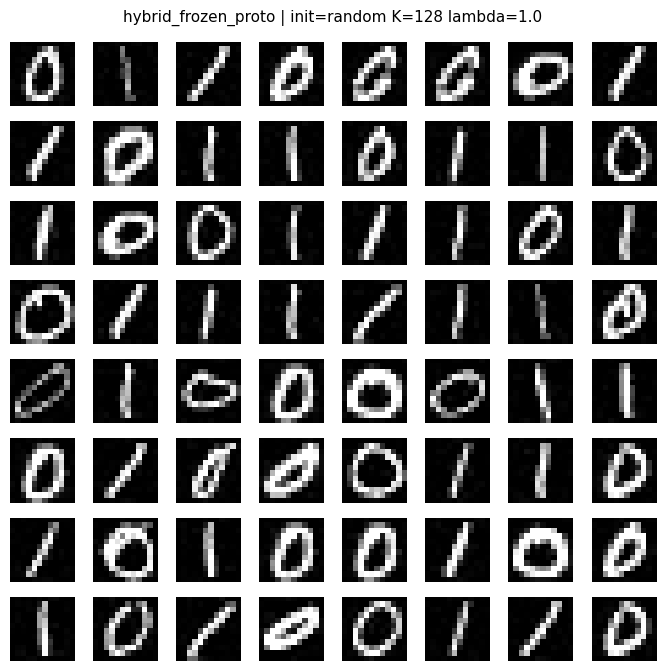

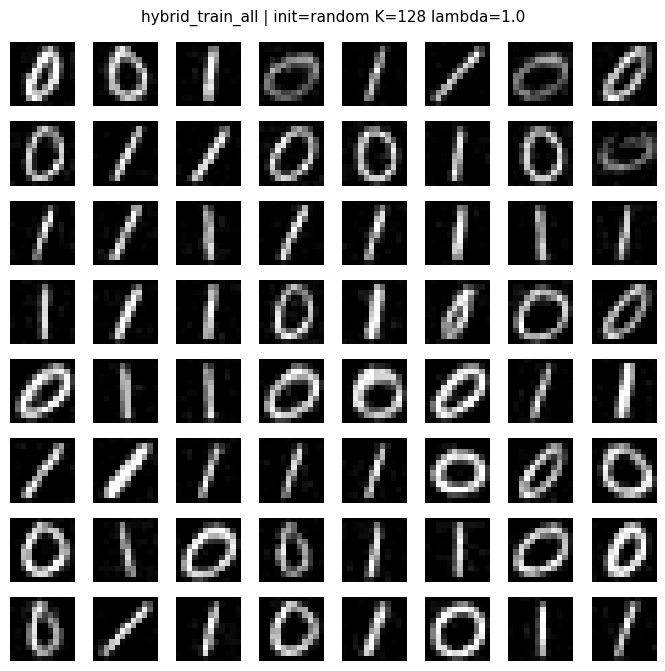

In [16]:
for row in final_results:
    show_image_grid(row["samples"], f"{row['mode']} | init={row['init']} K={row['K']} lambda={row['lambda']}")

## Interpretation Checklist

- If `hybrid_frozen_proto` beats `dense_frozen`, the conv/Bernoulli hidden layer helps even when prototypes cannot memorize by moving.
- If `dense_train_proto` nearly matches `hybrid_train_all`, most of the gain is prototype drift/memorization.
- If `hybrid_train_all` beats both, the two components are complementary.
- `sample->sample` is a crude diversity diagnostic: very small values indicate many duplicate or near-duplicate samples.
- Component norms show whether the conv score is dynamically relevant near low noise.